# Regularization for High Dimensional Medical Data

Goal: Work with high dimensional medical like data and apply regularization.

,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_291,gene_292,gene_293,gene_294,gene_295,gene_296,gene_297,gene_298,gene_299,inflammation_index
0,-0.413762,-1.341705,-0.836130,-0.081549,0.388992,-0.713327,1.176060,-0.203615,0.005939,0.182100,...,-1.809690,-1.009124,0.612681,0.665589,-0.766963,-0.003623,-0.045614,1.222965,0.198327,-260.174091
1,-0.993457,1.046645,-0.351241,0.357402,1.265467,-0.307238,-0.933542,-1.873233,0.531790,1.356611,...,0.754421,1.965332,0.026315,1.911160,-0.966264,0.639589,0.760265,0.696942,0.442368,302.867054
2,0.700770,1.153407,0.388745,0.771588,-1.571041,1.019605,0.885983,0.880932,0.387757,0.885766,...,0.058574,0.591248,0.370691,0.219250,1.300698,0.995020,-1.702196,-0.562065,-0.284328,-74.237541
3,0.140672,-0.629650,1.054178,-0.155036,1.626650,-0.278914,-1.451338,-0.271207,0.068599,-2.086635,...,2.620574,-1.329892,0.663562,1.484926,-0.922823,-0.839129,-0.363438,-0.495795,0.570789,9.058225
4,0.021490,-0.808659,-0.323399,0.058705,0.498630,0.125635,-0.275433,-2.056776,0.496276,0.753782,...,0.146109,-2.346808,-0.443179,-0.769098,-0.103452,-0.738195,-1.260370,0.479914,0.499986,364.661904


Shape: (80, 301)
        count      mean       std       min       25%       50%       75%  \
gene_0   80.0 -0.251484  1.010015 -3.489531 -0.913786 -0.265137  0.520025   
gene_1   80.0 -0.003927  0.951264 -2.100680 -0.558789 -0.024147  0.669243   
gene_2   80.0  0.123708  0.981661 -1.822583 -0.598673  0.143635  0.832603   
gene_3   80.0 -0.076566  0.913269 -2.094603 -0.687387 -0.004361  0.413698   
gene_4   80.0  0.012699  0.999408 -3.007413 -0.649998 -0.122263  0.699850   
gene_5   80.0 -0.027341  1.034734 -2.285499 -0.599575  0.010643  0.588694   
gene_6   80.0 -0.111751  1.058984 -2.532101 -0.888202 -0.123929  0.532075   
gene_7   80.0 -0.128621  0.934848 -2.259976 -0.756327 -0.108951  0.427515   
gene_8   80.0  0.208133  0.967401 -2.353640 -0.506388  0.299159  0.980074   
gene_9   80.0  0.216952  1.078998 -2.555990 -0.499422  0.183931  0.816500   

             max  
gene_0  2.323629  
gene_1  2.290467  
gene_2  2.384374  
gene_3  2.565204  
gene_4  2.061826  
gene_5  2.865204  
ge

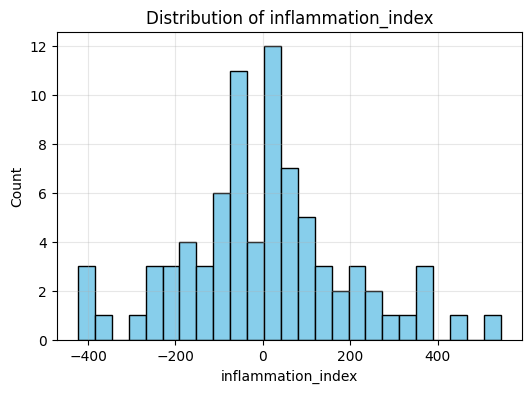

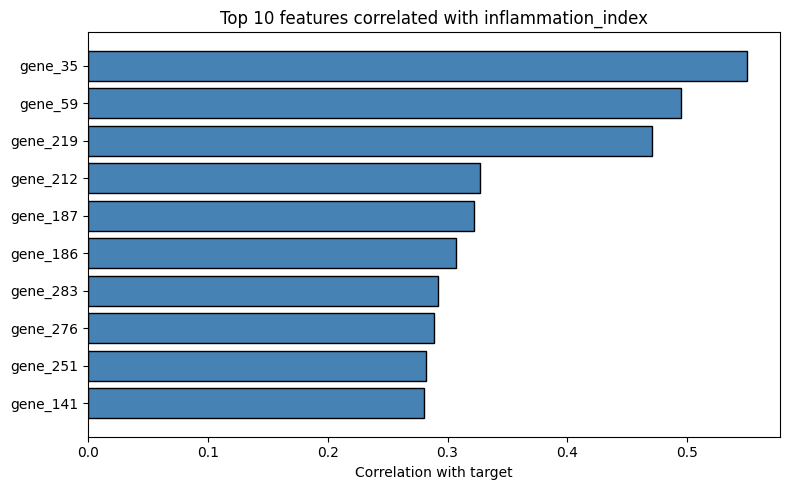

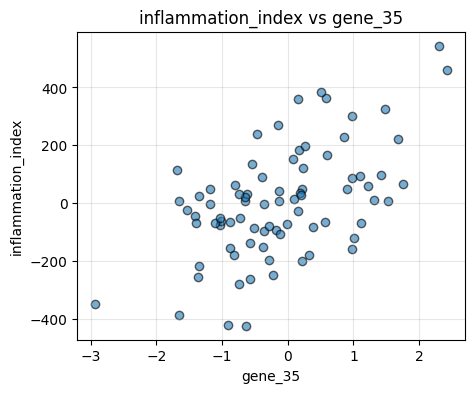

The most correlated feature with inflammation_index is: 'gene_35' (0.55)
Baseline MSE: 41835.386627300715


In [13]:
import sys
sys.path.append("../")  # parent folder
from workshop_utils import load_dataset, basic_train_test_split

import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import sys
sys.path.append("../")  # parent folder

# ===========================
# 0. Explore the Omics dataset
# ===========================

# Load high-dimensional dataset
df = load_dataset("omics")

# 0.1: Inspect the dataset
display(df.head())
print(f"Shape: {df.shape}")
print(df.describe().T.head(10))  # summarize first few numeric features

# 0.3: Visualize the target distribution (simple matplotlib)
target = "inflammation_index"
plt.figure(figsize=(6,4))
plt.hist(df[target], bins=25, color="skyblue", edgecolor="black")
plt.title(f"Distribution of {target}")
plt.xlabel(target)
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.show()

# 0.4: Pairwise correlations with the target (top 10 features)
corrs = df.corr(numeric_only=True)[target].drop(target).sort_values(ascending=False)
top_corrs = corrs.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_corrs.index[::-1], top_corrs.values[::-1], color="steelblue", edgecolor="black")
plt.title(f"Top 10 features correlated with {target}")
plt.xlabel("Correlation with target")
plt.tight_layout()
plt.show()

# 0.5: Optional scatterplot for the strongest correlation
top_feature = top_corrs.index[0]
plt.figure(figsize=(5,4))
plt.scatter(df[top_feature], df[target], alpha=0.6, edgecolor="black")
plt.title(f"{target} vs {top_feature}")
plt.xlabel(top_feature)
plt.ylabel(target)
plt.grid(alpha=0.3)
plt.show()

print(f"The most correlated feature with {target} is: '{top_feature}' ({top_corrs.iloc[0]:.2f})")

X_train, X_test, y_train, y_test = basic_train_test_split(
    df, target="inflammation_index"
)

# Baseline model: plain OLS (no regularization)
base_model = LinearRegression()
base_model.fit(X_train, y_train)
base_pred = base_model.predict(X_test)
print("Baseline MSE:", mean_squared_error(y_test, base_pred))


In [15]:

# ----------------------------------
# TODO 2.1: Ridge with cross validation (with scaling)
# ----------------------------------
ridge_pipe = Pipeline(
    steps=[
        ("scale", StandardScaler()),
        ("ridge", Ridge())
    ]
)

ridge_param_grid = {
    "ridge__alpha": [0.1, 1.0, 10.0]
}

ridge_cv = GridSearchCV(ridge_pipe, ridge_param_grid, cv=5)
ridge_cv.fit(X_train, y_train)

ridge_pred = ridge_cv.predict(X_test)
print("Ridge best alpha:", ridge_cv.best_params_)
print("Ridge MSE:", mean_squared_error(y_test, ridge_pred))

# Extract ridge coefficients (from the model inside the pipeline)
ridge_best_model = ridge_cv.best_estimator_["ridge"]
ridge_coefs = pd.Series(
    ridge_best_model.coef_,
    index=X_train.columns,
    name="ridge_coef"
)
print("\nTop 10 Ridge coefficients (by absolute value):")
display(ridge_coefs.reindex(ridge_coefs.abs().sort_values(ascending=False).head(10).index))


Ridge best alpha: {'ridge__alpha': 0.1}
Ridge MSE: 42665.28743373897

Top 10 Ridge coefficients (by absolute value):


gene_35     17.185820
gene_59     15.472886
gene_27     12.983965
gene_219    12.917911
gene_154   -12.430848
gene_260   -11.580319
gene_283    11.416082
gene_297    11.032535
gene_276    10.982069
gene_212    10.752478
Name: ridge_coef, dtype: float64

In [16]:

# ----------------------------------
# TODO 2.2: Lasso with cross validation (with scaling)
# ----------------------------------
lasso_pipe = Pipeline(
    steps=[
        ("scale", StandardScaler()),
        ("lasso", Lasso(max_iter=5000))
    ]
)

lasso_param_grid = {
    "lasso__alpha": [0.001, 0.01, 0.1]
}

lasso_cv = GridSearchCV(lasso_pipe, lasso_param_grid, cv=5)
lasso_cv.fit(X_train, y_train)

lasso_pred = lasso_cv.predict(X_test)
print("Lasso best alpha:", lasso_cv.best_params_)
print("Lasso MSE:", mean_squared_error(y_test, lasso_pred))

# Extract lasso coefficients
lasso_best_model = lasso_cv.best_estimator_["lasso"]
lasso_coefs = pd.Series(
    lasso_best_model.coef_,
    index=X_train.columns,
    name="lasso_coef"
)

# Features that were selected (nonzero coefficients)
selected_features = lasso_coefs[lasso_coefs != 0]
print(f"Lasso selected {len(selected_features)} of {len(lasso_coefs)} features.")
display(selected_features.reindex(selected_features.abs().sort_values(ascending=False).head(15).index))



Lasso best alpha: {'lasso__alpha': 0.1}
Lasso MSE: 620.1725730029857
Lasso selected 68 of 300 features.


gene_35     88.665080
gene_59     81.997398
gene_219    73.362082
gene_297    65.300478
gene_276    54.384214
gene_5      42.609350
gene_128    41.225312
gene_271    32.652505
gene_144    23.166878
gene_108    17.458815
gene_11     -2.687586
gene_110    -2.546869
gene_298    -2.539337
gene_51     -2.510643
gene_283     2.455631
Name: lasso_coef, dtype: float64

In [17]:
# ----------------------------------
# Helper function with scaling
# ----------------------------------
def train_regularized_model(X_train, y_train, model_type="ridge"):
    if model_type == "ridge":
        pipe = Pipeline(
            steps=[
                ("scale", StandardScaler()),
                ("model", Ridge())
            ]
        )
        grid = {"model__alpha": [0.1, 1.0, 10.0]}
    else:
        pipe = Pipeline(
            steps=[
                ("scale", StandardScaler()),
                ("model", Lasso(max_iter=5000))
            ]
        )
        grid = {"model__alpha": [0.001, 0.01, 0.1]}
    search = GridSearchCV(pipe, grid, cv=5)
    search.fit(X_train, y_train)
    return search

# usage
ridge_search = train_regularized_model(X_train, y_train, model_type="ridge")
lasso_search = train_regularized_model(X_train, y_train, model_type="lasso")

# extract selected from the helper
lasso_best = lasso_search.best_estimator_["model"]
lasso_coefs = pd.Series(lasso_best.coef_, index=X_train.columns)
selected = lasso_coefs[lasso_coefs != 0]
# display(selected)


### Interpretation

- Which variables have the **largest absolute coefficients** under Ridge?  
  → These are most strongly associated with SBP when all others are controlled for.

- Which variables were **set to zero** under Lasso?  
  → These are features that Lasso considered unimportant (they add little predictive value).

- Compare the selected variables to those that had small p-values in the previous statsmodels analysis.
  - Are the same variables identified as important?
  - What might explain differences between significance and predictive strength?

**Key takeaway:**  
Regularization offers a scalable alternative to classical inference.  
Where p-values test each variable individually, Lasso and Ridge automatically identify and shrink uninformative features — a practical approach when there are many correlated predictors.


In [19]:


# ==========================
# PART 2: EXERCISE on simpler BP dataset
# ==========================

# 1. Load the simpler dataset
bp_df = load_dataset("bp")

# 2. Add the interaction term
bp_df["bmi_sex_interaction"] = bp_df["bmi"] * bp_df["sex"]

# 3. Split into train and test sets
features = ["age", "bmi", "sodium", "exercise_minutes", "sex", "bmi_sex_interaction"]
X_train_bp, X_test_bp, y_train_bp, y_test_bp = basic_train_test_split(bp_df, target="sbp")

# 4. Ridge Regression (with scaling)
bp_ridge_pipe = Pipeline(
    steps=[
        ("scale", StandardScaler()),
        ("ridge", Ridge())
    ]
)
bp_ridge_grid = {"ridge__alpha": [1.0, 10.0]}
bp_ridge_cv = GridSearchCV(bp_ridge_pipe, bp_ridge_grid, cv=5)
bp_ridge_cv.fit(X_train_bp[features], y_train_bp)

bp_ridge_pred = bp_ridge_cv.predict(X_test_bp[features])
print("\n[BP] Ridge best alpha:", bp_ridge_cv.best_params_)
print("[BP] Ridge MSE:", mean_squared_error(y_test_bp, bp_ridge_pred))

bp_ridge_best = bp_ridge_cv.best_estimator_["ridge"]
bp_ridge_coefs = pd.Series(bp_ridge_best.coef_, index=features, name="ridge_coef")
print("\n[BP] Ridge coefficients:")
display(bp_ridge_coefs.round(3))

# 5. Lasso Regression (with scaling)
bp_lasso_pipe = Pipeline(
    steps=[
        ("scale", StandardScaler()),
        ("lasso", Lasso(max_iter=5000))
    ]
)
bp_lasso_grid = {"lasso__alpha": [ 10,20,30]}
bp_lasso_cv = GridSearchCV(bp_lasso_pipe, bp_lasso_grid, cv=5)
bp_lasso_cv.fit(X_train_bp[features], y_train_bp)

bp_lasso_pred = bp_lasso_cv.predict(X_test_bp[features])
print("[BP] Lasso best alpha:", bp_lasso_cv.best_params_)
print("[BP] Lasso MSE:", mean_squared_error(y_test_bp, bp_lasso_pred))

bp_lasso_best = bp_lasso_cv.best_estimator_["lasso"]
bp_lasso_coefs = pd.Series(bp_lasso_best.coef_, index=features, name="lasso_coef")
print("\n[BP] Lasso coefficients:")
display(bp_lasso_coefs.round(3))

# 6. Identify selected features (nonzero)
bp_selected = bp_lasso_coefs[bp_lasso_coefs != 0]
print(f"[BP] Lasso selected {len(bp_selected)} out of {len(bp_lasso_coefs)} features.")
display(bp_selected.reindex(bp_selected.abs().sort_values(ascending=False).index))



[BP] Ridge best alpha: {'ridge__alpha': 1.0}
[BP] Ridge MSE: 29.62917019904633

[BP] Ridge coefficients:


age                     4.733
bmi                     9.091
sodium                  2.464
exercise_minutes       -3.443
sex                     5.562
bmi_sex_interaction    10.571
Name: ridge_coef, dtype: float64

[BP] Lasso best alpha: {'lasso__alpha': 10}
[BP] Lasso MSE: 248.36740905302895

[BP] Lasso coefficients:


age                    0.000
bmi                    0.000
sodium                 0.000
exercise_minutes      -0.000
sex                    0.000
bmi_sex_interaction    6.048
Name: lasso_coef, dtype: float64

[BP] Lasso selected 1 out of 6 features.


bmi_sex_interaction    6.048338
Name: lasso_coef, dtype: float64